# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [2]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [3]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [200]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
import numpy as np

# ── 1. Wrap function as sklearn-compatible class ───────────────────────────────
class DecisionTreeRandomSearch(BaseEstimator, ClassifierMixin):
    def __init__(self, n_iter=400, n_splits=10, random_state=0):
        self.n_iter       = n_iter
        self.n_splits     = n_splits
        self.random_state = random_state

        # these get populated after fit()
        self.best_model_   = None
        self.best_params_  = None
        self.best_score_   = None
        self.y_score_      = None
        self.info_         = None

    def fit(self, X, y):
        param_list = {
            'max_depth':         list(np.arange(2, 50)),
            'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
            'min_samples_leaf':  [5, 10, 20, 30, 50, 100, 150],
            'criterion':         ['gini', 'entropy']
        }

        random_search = RandomizedSearchCV(
            DecisionTreeClassifier(),
            param_distributions=param_list,
            cv=KFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state),
            n_jobs=-1,
            refit=True,
            n_iter=self.n_iter,
            random_state=self.random_state,
        )
        random_search.fit(X, y)

        self.best_model_  = random_search.best_estimator_
        self.best_params_ = random_search.best_params_
        self.best_score_  = random_search.best_score_

        self.best_model_.fit(X, y)

        # store full info dict
        self.info_ = {
            'best_params':         self.best_params_,
            'best_cv_score':       self.best_score_,
            'n_features':          self.best_model_.n_features_in_,
            'feature_importances': self.best_model_.feature_importances_,
            'n_classes':           self.best_model_.n_classes_,
            'classes':             self.best_model_.classes_,
            'tree_depth':          self.best_model_.get_depth(),
            'n_leaves':            self.best_model_.get_n_leaves(),
            'cv_results':          random_search.cv_results_,
        }

        print("="*55)
        print("DECISION TREE — TRAINING SUMMARY")
        print("="*55)
        print(f"  Best params   : {self.best_params_}")
        print(f"  Best CV score : {self.best_score_:.4f}")
        print(f"  Tree depth    : {self.info_['tree_depth']}")
        print(f"  Leaves        : {self.info_['n_leaves']}")
        print("="*55)

        return self                          # ← required by sklearn

    def predict(self, X):
        return self.best_model_.predict(X)

    def predict_proba(self, X):
        self.y_score_ = self.best_model_.predict_proba(X)
        return self.y_score_




In [102]:
def train_decision_tree(X_train, y_train, X_test,
                        n_iter=400, n_splits=10, random_state=0):

    # ── 1. Search space ───────────────────────────────────────────────────────
    param_list = {
        'max_depth':         list(np.arange(2, 50)),
        'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
        'min_samples_leaf':  [5, 10, 20, 30, 50, 100, 150],
        'criterion':         ['gini', 'entropy']
    }

    # ── 2. Random search ──────────────────────────────────────────────────────
    random_search = RandomizedSearchCV(
        DecisionTreeClassifier(),
        param_distributions=param_list,
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_weighted',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
    )
    random_search.fit(X_train, y_train)

    # ── 3. Best model ─────────────────────────────────────────────────────────
    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_train)

    # ── 4. Predict ────────────────────────────────────────────────────────────
    y_pred  = best_model.predict(X_test)
    y_score = best_model.predict_proba(X_test)   # ← shape (n_samples, n_classes)

    # ── 5. Collect all attributes ─────────────────────────────────────────────
    info = {
        # best model and params
        'best_model':           best_model,
        'best_params':          random_search.best_params_,
        'best_cv_score':        random_search.best_score_,

        # tree structure
        'n_features':           best_model.n_features_in_,
        'feature_importances':  best_model.feature_importances_,
        'n_classes':            best_model.n_classes_,
        'classes':              best_model.classes_,
        'tree_depth':           best_model.get_depth(),
        'n_leaves':             best_model.get_n_leaves(),

        # search details
        'n_iter':               n_iter,
        'n_splits':             n_splits,
        'cv_results':           random_search.cv_results_,
    }

    # ── 6. Print summary ──────────────────────────────────────────────────────
    print("="*55)
    print("DECISION TREE — TRAINING SUMMARY")
    print("="*55)
    print(f"  Best params       : {info['best_params']}")
    print(f"  Best CV score     : {info['best_cv_score']:.4f}")
    print(f"  Tree depth        : {info['tree_depth']}")
    print(f"  Number of leaves  : {info['n_leaves']}")
    print(f"  Features used     : {info['n_features']}")
    print(f"  Classes           : {info['classes']}")
    print(f"  y_score shape     : {y_score.shape}")   # (n_samples, n_classes)
    print("="*55)

    return y_pred, y_score, info          # ← added y_score here


# READ DATAFRAME

In [5]:
file_path = "../1.DATASET/CMI_FINAL_OD.csv"
df=pd.read_csv(file_path)

In [6]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,5,0,16.877316,46.000,50.800000,82.152821,4.611111,17.883041,6.500000,2.0,2.668550,1492.000000,41.586230,9.213770,1.0,19.541300,32.690900,2.0
1,1,9,0,14.035590,48.000,46.000000,90.666667,8.000000,18.204545,11.000000,2.0,2.579490,1498.650000,42.029150,3.970850,1.0,15.410700,27.055200,0.0
2,2,10,1,16.648696,56.500,75.600000,82.333333,27.000000,12.450000,10.000000,3.0,3.389932,1796.890000,59.788250,15.811750,2.0,25.634700,42.380000,0.0
3,3,9,0,18.292347,56.000,81.600000,79.000000,23.000000,18.204545,7.000000,3.0,3.841910,1923.440000,62.775700,18.824300,2.0,26.479800,45.996600,1.0
4,4,18,1,17.937682,54.626,76.139461,90.152104,12.000000,26.463732,8.003205,3.0,12.054014,2652.510000,60.327711,15.811750,2.0,29.912400,42.380000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,7,1,16.130585,46.070,48.700252,81.861037,6.500000,18.075000,7.000000,1.0,2.625946,1490.847845,45.526276,3.173977,1.0,18.024600,31.583004,0.0
8378,8456,10,1,17.300000,56.130,77.531978,79.833333,8.500000,13.575000,5.000000,3.0,4.987853,1678.330810,69.880763,7.651215,1.0,22.983200,36.475662,1.0
8379,8457,10,1,40.937571,49.560,143.030726,82.166667,21.500000,16.840263,9.500000,4.0,3.990512,1547.346725,107.979706,35.051020,2.0,31.594712,35.106855,0.0
8380,8458,15,1,22.500000,63.790,130.236404,88.395702,10.000000,26.417470,10.500000,2.0,4.967841,1674.735823,103.517750,26.718654,2.0,46.467581,57.530686,2.0


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scl = StandardScaler()

features = [
    'Basic_Demos-Age', 'Basic_Demos-Sex', 'Physical-BMI',
    'Physical-Height', 'Physical-Weight', 'Physical-MAP_CAL',
    'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL',
    'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
    'BIA-BIA_FFM', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
    'BIA-BIA_TBW'
]

df[features] = scl.fit_transform(df[features])

In [8]:
#df=df[(df['sii']!=3)|(df['sii']!=2)].copy()

In [9]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])


# Data Preparation

In [10]:
X.shape

(8382, 17)

In [11]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [12]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [13]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

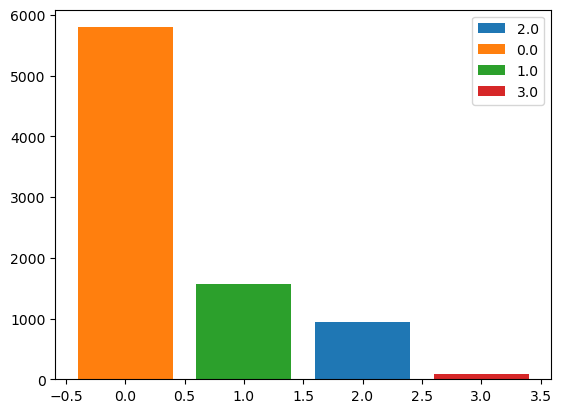

In [14]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [15]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [17]:
X_train.shape

(5867, 17)

In [18]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [19]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

## Classification

In [20]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [201]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['gini', 'entropy']
}

dt_cl_sii = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=0.002, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list,
    cv=KFold(n_splits=10, shuffle=True, random_state=0),
    scoring='f1_weighted',
    n_jobs=-1,
    refit=True,
    n_iter=400,
)

random_search.fit(X_train, y_train)
dt_cl_sii = random_search.best_estimator_

In [202]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 20, 'max_depth': 18, 'criterion': 'entropy'} 0.5905138762541111


In [203]:
dt_cl_sii = random_search.best_estimator_
dt_cl_sii.fit(X_train, y_train)
y_pred0 = dt_cl_sii.predict(X_test)

In [204]:
print('Accuracy %s' % accuracy_score(y_test, y_pred0))
print('F1-score %s' % f1_score(y_test, y_pred0, average=None))
print(classification_report(y_test, y_pred0))

Accuracy 0.6644135188866799
F1-score [0.80301887 0.17821782 0.07453416 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.92      0.80      1738
         1.0       0.27      0.13      0.18       470
         2.0       0.29      0.04      0.07       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.66      2515
   macro avg       0.32      0.27      0.26      2515
weighted avg       0.58      0.66      0.60      2515



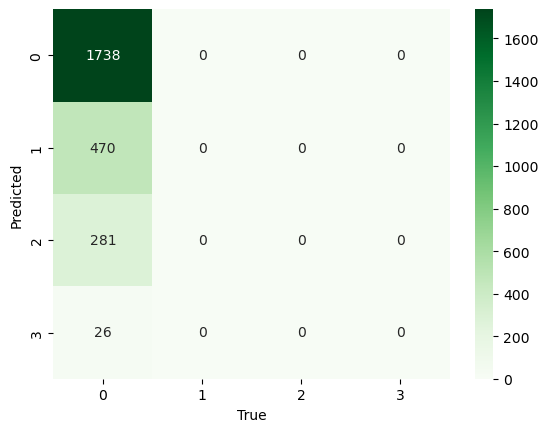

In [78]:
cf = confusion_matrix(y_test, y_pred0)
sns.heatmap(cf, annot=True, cmap="Greens",fmt='g')
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

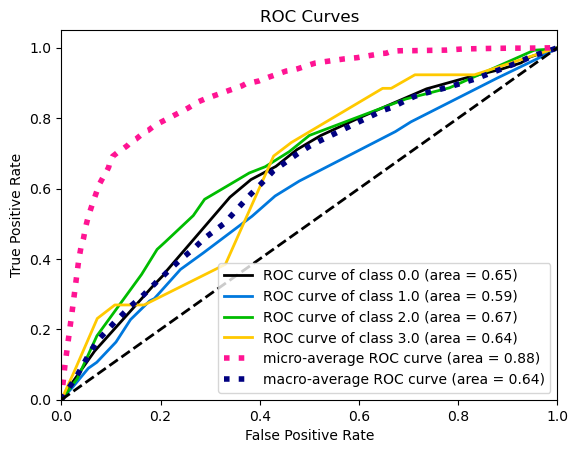

In [27]:
y_score = dt_cl_sii.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

## PCA

In [28]:
from sklearn.decomposition import PCA

In [29]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolor='k', alpha=0.7)
    plt.show()

In [30]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
print(X_train.shape, X_pca.shape)

(5867, 17) (5867, 2)


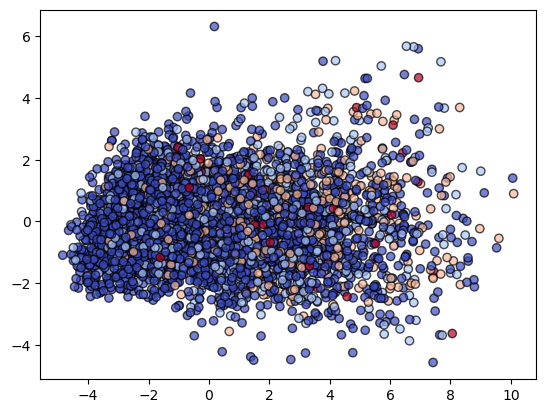

In [31]:
plot_pca(X_pca, y_train)

# Oversampling

In [32]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

### RandomOverSampler

In [33]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1.0: 4056, 0.0: 4056, 2.0: 4056, 3.0: 4056})


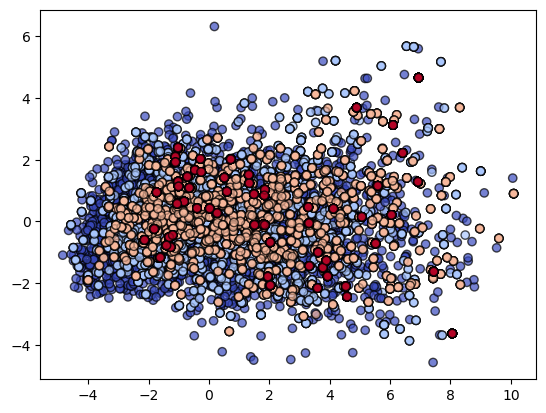

In [34]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [35]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['feature_importances'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 31, 'criterion': 'entropy'}
  Best CV score     : 0.7914
  Tree depth        : 22
  Number of leaves  : 699
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 31, 'criterion': 'entropy'}
[0.0722378  0.01151813 0.07457087 0.12614079 0.06710364 0.05305347
 0.06230324 0.07094911 0.04120159 0.02092789 0.09956929 0.07823966
 0.04029469 0.07091001 0.01043205 0.03809362 0.06245414]
0.7914191648566045


Accuracy 0.45964214711729623
F1-score [0.62475182 0.22282609 0.21128451 0.02816901]
              precision    recall  f1-score   support

         0.0       0.74      0.54      0.62      1738
         1.0       0.19      0.26      0.22       470
         2.0       0.16      0.31      0.21       281
         3.0       0.02      0.04      0.03        26

    accuracy                           0.46      2515
   macro avg       0.28      0.29      0.27      2515
weighted avg       0.56      0.46      0.50      2515



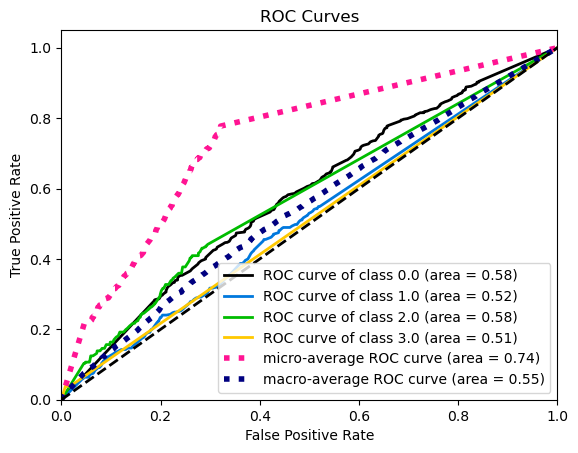

In [36]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

plot_roc(y_test, y_score)
plt.show()



### SMOTE

In [279]:

sm = SMOTE(random_state=42, sampling_strategy={1:2500,2:2000,3:1500})
X_res, y_res = sm.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 4056, 1.0: 2500, 2.0: 2000, 3.0: 1500})


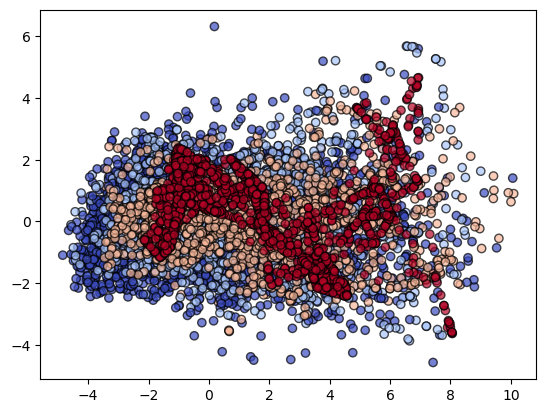

In [280]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [281]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 26, 'criterion': 'gini'}
  Best CV score     : 0.6095
  Tree depth        : 26
  Number of leaves  : 748
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 26, 'criterion': 'gini'}
0.6095370223516265


Accuracy 0.5530815109343936
F1-score [0.72021183 0.2344245  0.18487395 0.02247191]
              precision    recall  f1-score   support

         0.0       0.74      0.70      0.72      1738
         1.0       0.23      0.24      0.23       470
         2.0       0.18      0.20      0.18       281
         3.0       0.02      0.04      0.02        26

    accuracy                           0.55      2515
   macro avg       0.29      0.29      0.29      2515
weighted avg       0.57      0.55      0.56      2515



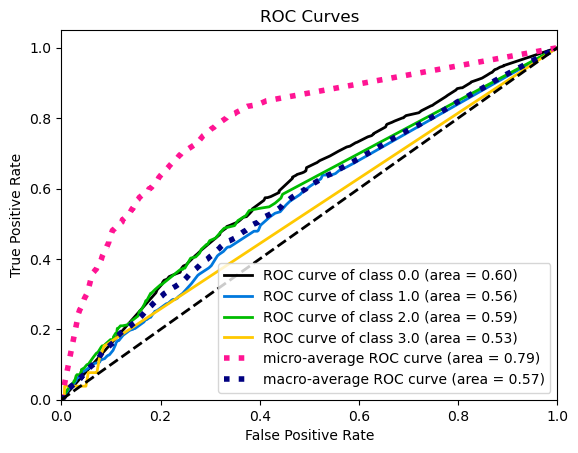

In [282]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### ADASYN

In [283]:
ada = ADASYN(random_state=42,sampling_strategy={1:2500,2:2000,3:1500})
X_res, y_res = ada.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 4056, 1.0: 2560, 2.0: 1834, 3.0: 1514})


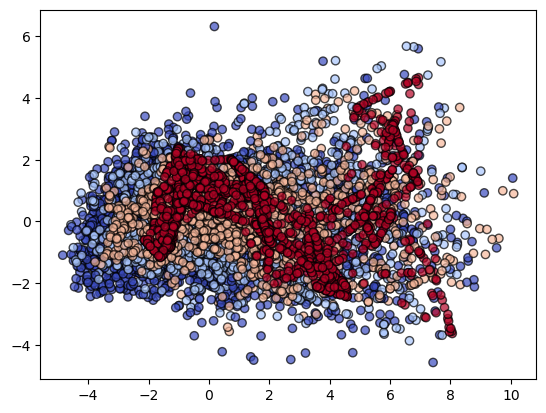

In [284]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [285]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 26, 'criterion': 'gini'}
  Best CV score     : 0.6038
  Tree depth        : 24
  Number of leaves  : 757
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 26, 'criterion': 'gini'}
0.6037881768305808


Accuracy 0.5395626242544732
F1-score [0.70807453 0.23505572 0.15465729 0.        ]
              precision    recall  f1-score   support

         0.0       0.73      0.69      0.71      1738
         1.0       0.22      0.25      0.24       470
         2.0       0.15      0.16      0.15       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.54      2515
   macro avg       0.28      0.27      0.27      2515
weighted avg       0.56      0.54      0.55      2515



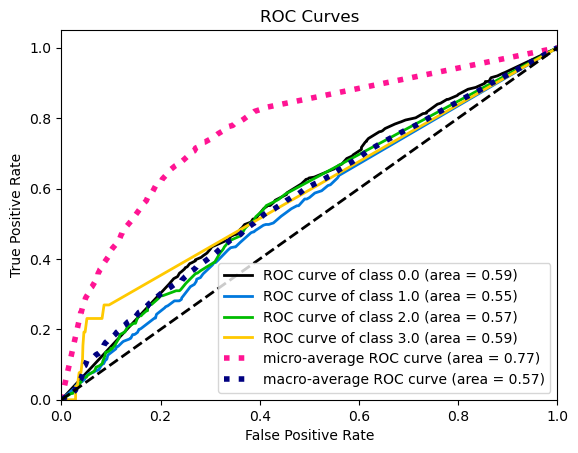

In [286]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


# Undersampling

In [45]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

### RandomUnderSampler

In [46]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 59, 1.0: 59, 2.0: 59, 3.0: 59})


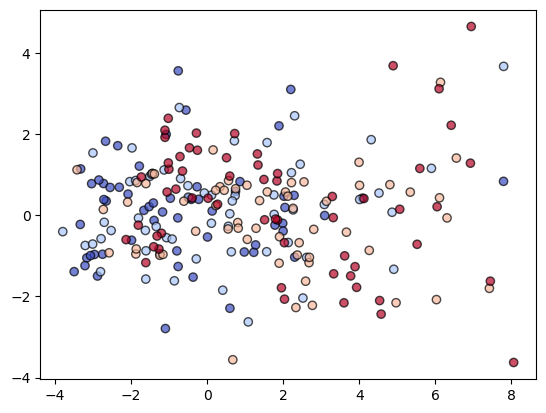

In [47]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [48]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.2, 'min_samples_leaf': 10, 'max_depth': 32, 'criterion': 'gini'}
  Best CV score     : 0.4020
  Tree depth        : 6
  Number of leaves  : 9
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.2, 'min_samples_leaf': 10, 'max_depth': 32, 'criterion': 'gini'}
0.4019927536231885


Accuracy 0.3836978131212724
F1-score [0.52975048 0.24019608 0.25203252 0.03686636]
              precision    recall  f1-score   support

         0.0       0.80      0.40      0.53      1738
         1.0       0.19      0.31      0.24       470
         2.0       0.18      0.44      0.25       281
         3.0       0.02      0.15      0.04        26

    accuracy                           0.38      2515
   macro avg       0.30      0.33      0.26      2515
weighted avg       0.61      0.38      0.44      2515



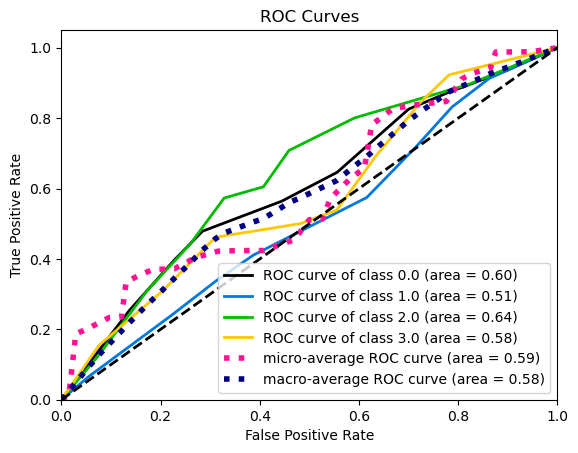

In [49]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### CondensedNearestNeighbour

In [50]:
import warnings
warnings.simplefilter("ignore")

In [51]:
cnn = CondensedNearestNeighbour(random_state=42, n_jobs=10)
X_res, y_res = cnn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 397, 1.0: 244, 2.0: 207, 3.0: 59})


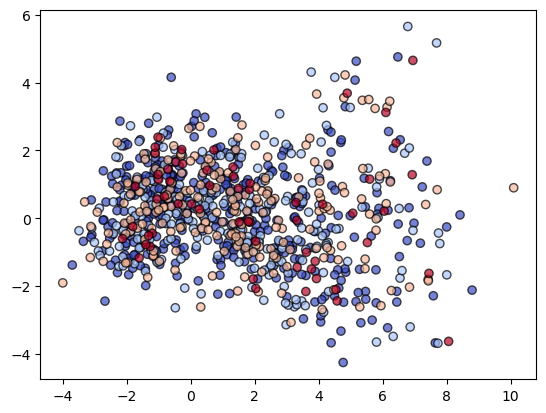

In [52]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [53]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.002, 'min_samples_leaf': 150, 'max_depth': 46, 'criterion': 'entropy'}
  Best CV score     : 0.4411
  Tree depth        : 4
  Number of leaves  : 5
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.002, 'min_samples_leaf': 150, 'max_depth': 46, 'criterion': 'entropy'}
0.44113553113553117


Accuracy 0.6910536779324056
F1-score [0.81730543 0.         0.         0.        ]
              precision    recall  f1-score   support

         0.0       0.69      1.00      0.82      1738
         1.0       0.00      0.00      0.00       470
         2.0       0.00      0.00      0.00       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.69      2515
   macro avg       0.17      0.25      0.20      2515
weighted avg       0.48      0.69      0.56      2515



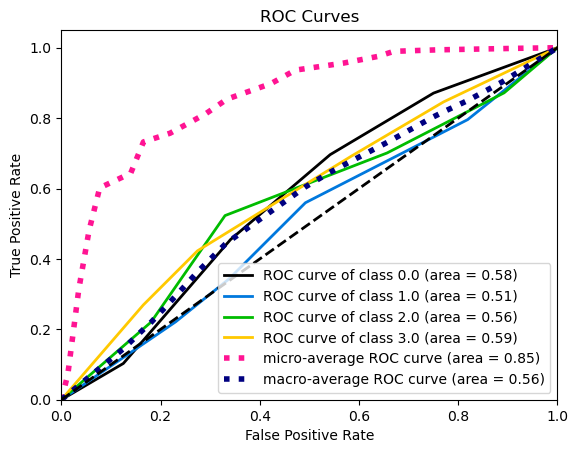

In [54]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()



### Tomek Links

In [287]:
tl = TomekLinks(sampling_strategy='majority')
X_res, y_res = tl.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 3642, 1.0: 1097, 2.0: 655, 3.0: 59})


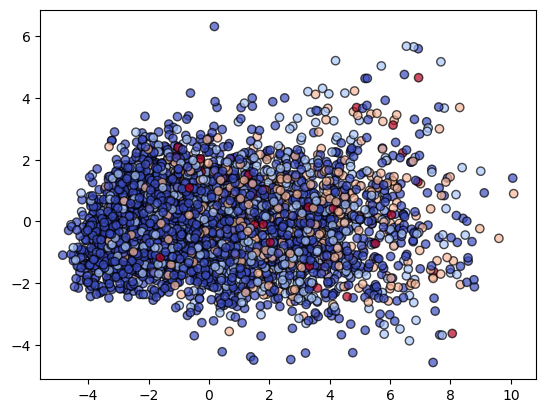

In [288]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [289]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.01, 'min_samples_leaf': 5, 'max_depth': 23, 'criterion': 'entropy'}
  Best CV score     : 0.5770
  Tree depth        : 18
  Number of leaves  : 198
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.01, 'min_samples_leaf': 5, 'max_depth': 23, 'criterion': 'entropy'}
0.5769660002349688


Accuracy 0.6353876739562624
F1-score [0.78164475 0.18481013 0.05373134 0.        ]
              precision    recall  f1-score   support

         0.0       0.71      0.87      0.78      1738
         1.0       0.23      0.16      0.18       470
         2.0       0.17      0.03      0.05       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.64      2515
   macro avg       0.28      0.26      0.26      2515
weighted avg       0.55      0.64      0.58      2515



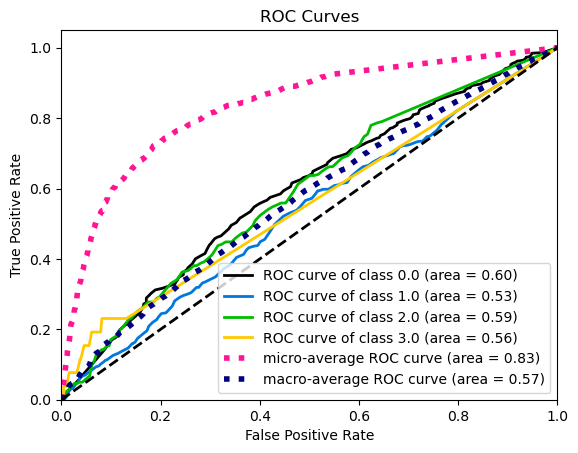

In [290]:
# predict
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()



### Edited Nearest Neighbors

In [293]:
enn = EditedNearestNeighbours(sampling_strategy='majority')
X_res, y_res = enn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 1685, 1.0: 1097, 2.0: 655, 3.0: 59})


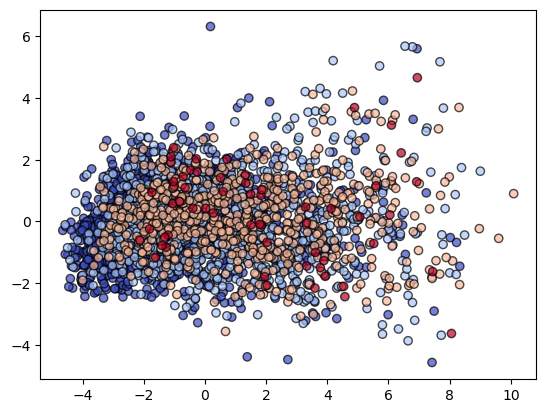

In [294]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [295]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.01, 'min_samples_leaf': 20, 'max_depth': 6, 'criterion': 'entropy'}
  Best CV score     : 0.5372
  Tree depth        : 6
  Number of leaves  : 48
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.01, 'min_samples_leaf': 20, 'max_depth': 6, 'criterion': 'entropy'}
0.5371755071482343


Accuracy 0.5423459244532803
F1-score [0.6974359  0.31210191 0.25477707 0.        ]
              precision    recall  f1-score   support

         0.0       0.79      0.63      0.70      1738
         1.0       0.25      0.42      0.31       470
         2.0       0.23      0.28      0.25       281
         3.0       0.00      0.00      0.00        26

    accuracy                           0.54      2515
   macro avg       0.32      0.33      0.32      2515
weighted avg       0.62      0.54      0.57      2515



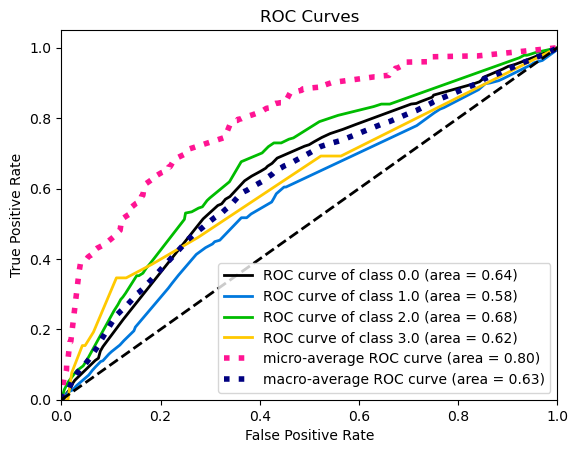

In [296]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


### Cluster Centroids

In [63]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids

In [64]:
cc = ClusterCentroids(
    estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42
)
X_res, y_res = cc.fit_resample(X, y)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0.0: 85, 1.0: 85, 2.0: 85, 3.0: 85})


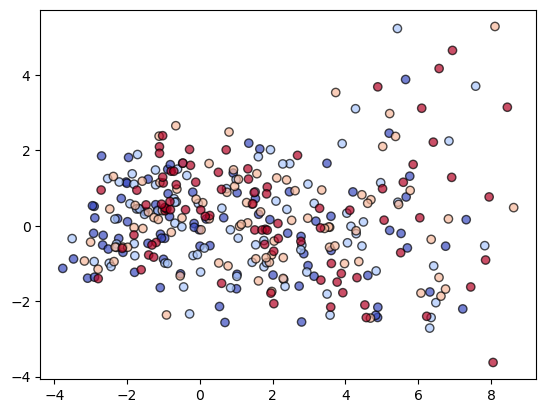

In [65]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

In [66]:
y_pred, y_score, info = train_decision_tree(X_res, y_res, X_test)

print(info['best_params'])
print(info['best_cv_score'])

DECISION TREE — TRAINING SUMMARY
  Best params       : {'min_samples_split': 0.1, 'min_samples_leaf': 5, 'max_depth': 39, 'criterion': 'entropy'}
  Best CV score     : 0.4529
  Tree depth        : 8
  Number of leaves  : 20
  Features used     : 17
  Classes           : [0. 1. 2. 3.]
  y_score shape     : (2515, 4)
{'min_samples_split': 0.1, 'min_samples_leaf': 5, 'max_depth': 39, 'criterion': 'entropy'}
0.45294117647058824


Accuracy 0.28151093439363817
F1-score [0.48892405 0.01214575 0.18975904 0.03571429]
              precision    recall  f1-score   support

         0.0       0.78      0.36      0.49      1738
         1.0       0.12      0.01      0.01       470
         2.0       0.16      0.22      0.19       281
         3.0       0.02      0.92      0.04        26

    accuracy                           0.28      2515
   macro avg       0.27      0.38      0.18      2515
weighted avg       0.58      0.28      0.36      2515



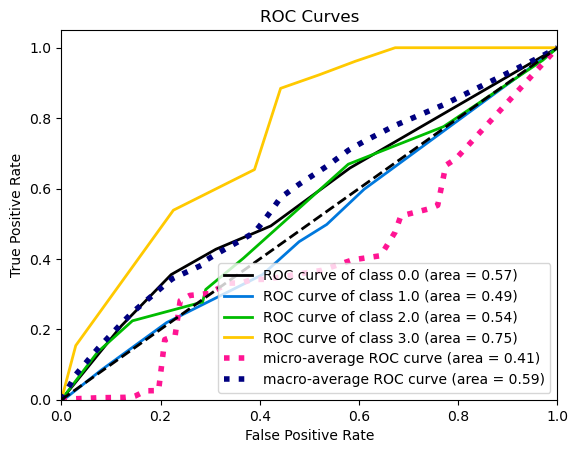

In [67]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# roc
plot_roc(y_test, y_score)
plt.show()


# MIX

In [208]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [267]:
over_dic={1:2500,2:2000,3:1500}
under_dic={0:3000}

In [268]:
over = SMOTE(random_state=42, sampling_strategy=over_dic)
# under = ClusterCentroids(
#     estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42,
#     sampling_strategy=under_dic
# )
under = TomekLinks(sampling_strategy='majority')

## DECISION TREE

In [269]:
pipeline = Pipeline([
    ('over',  over),
    ('under', under),
    ('clf',   DecisionTreeClassifier())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [270]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5256461232604374
F1-score [0.69202678 0.24517375 0.17721519 0.05263158]
              precision    recall  f1-score   support

         0.0       0.73      0.65      0.69      1738
         1.0       0.22      0.27      0.25       470
         2.0       0.16      0.20      0.18       281
         3.0       0.04      0.08      0.05        26

    accuracy                           0.53      2515
   macro avg       0.29      0.30      0.29      2515
weighted avg       0.57      0.53      0.54      2515



## DecisionTreeRandomSearch

In [271]:
from imblearn.pipeline import Pipeline          # ← key fix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [272]:
# ── Before anything ───────────────────────────────────────────────────────────
print("="*50)
print("BEFORE RESAMPLING")
print("="*50)
for cls, count in sorted(Counter(y_train).items()):
    print(f"  Class {cls} : {count} samples")
print(f"  TOTAL    : {len(y_train)} samples")

BEFORE RESAMPLING
  Class 0.0 : 4056 samples
  Class 1.0 : 1097 samples
  Class 2.0 : 655 samples
  Class 3.0 : 59 samples
  TOTAL    : 5867 samples


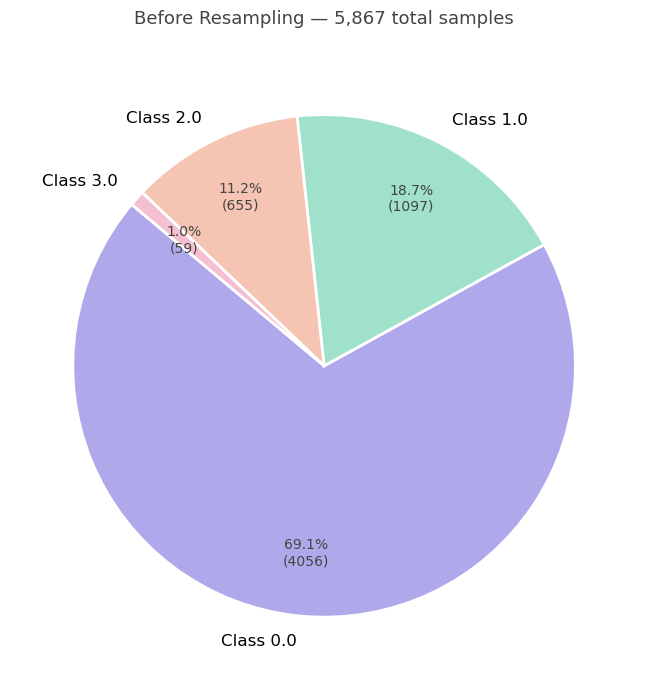

In [273]:
from collections import Counter
import matplotlib.pyplot as plt

# ── Before resampling ─────────────────────────────────────────────────────────
count   = Counter(y_train)
classes = [f"Class {cls}" for cls, _ in sorted(count.items())]
values  = [cnt for _, cnt in sorted(count.items())]
total   = len(y_train)

# ── Pastel colors ─────────────────────────────────────────────────────────────
colors = ['#AFA9EC', '#9FE1CB', '#F5C4B3', '#F4C0D1',
          '#B5D4F4', '#C0DD97', '#FAC775', '#F09595'][:len(classes)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    values,
    labels=classes,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * total / 100))})',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)

for text in texts:
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('#444441')

ax.set_title(
    f"Before Resampling — {total:,} total samples",
    fontsize=13,
    pad=20,
    color='#444441'
)

plt.tight_layout()
plt.show()

In [274]:
# ── After SMOTE (over) ────────────────────────────────────────────────────────
X_temp, y_temp = over.fit_resample(X_train, y_train)

print("\n" + "="*50)
print("AFTER SMOTE (over-sampling)")
print("="*50)
for cls, count in sorted(Counter(y_temp).items()):
    print(f"  Class {cls} : {count} samples")
print(f"  TOTAL    : {len(y_temp)} samples")

# ── After ClusterCentroids (under) ────────────────────────────────────────────
X_temp2, y_temp2 = under.fit_resample(X_temp, y_temp)

print("\n" + "="*50)
print("AFTER ClusterCentroids (under-sampling)")
print("="*50)
for cls, count in sorted(Counter(y_temp2).items()):
    print(f"  Class {cls} : {count} samples")
print(f"  TOTAL    : {len(y_temp2)} samples")


AFTER SMOTE (over-sampling)
  Class 0.0 : 4056 samples
  Class 1.0 : 2500 samples
  Class 2.0 : 2000 samples
  Class 3.0 : 1500 samples
  TOTAL    : 10056 samples

AFTER ClusterCentroids (under-sampling)
  Class 0.0 : 3949 samples
  Class 1.0 : 2500 samples
  Class 2.0 : 2000 samples
  Class 3.0 : 1500 samples
  TOTAL    : 9949 samples


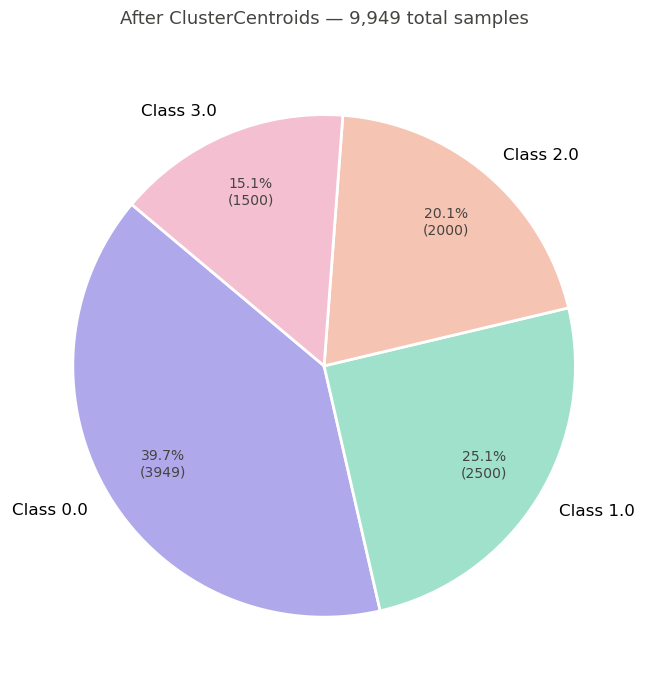

In [275]:
from collections import Counter
import matplotlib.pyplot as plt

# ── After ClusterCentroids (under) ───────────────────────────────────────────
X_temp2, y_temp2 = under.fit_resample(X_temp, y_temp)

count      = Counter(y_temp2)
classes    = [f"Class {cls}" for cls, _ in sorted(count.items())]
values     = [cnt for _, cnt in sorted(count.items())]
total      = len(y_temp2)

# ── Pastel colors ─────────────────────────────────────────────────────────────
colors = ['#AFA9EC', '#9FE1CB', '#F5C4B3', '#F4C0D1',
          '#B5D4F4', '#C0DD97', '#FAC775', '#F09595'][:len(classes)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    values,
    labels=classes,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p * total / 100))})',
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2),
)

# ── Font styling ──────────────────────────────────────────────────────────────
for text in texts:
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('#444441')

ax.set_title(
    f"After ClusterCentroids — {total:,} total samples",
    fontsize=13,
    pad=20,
    color='#444441'
)

plt.tight_layout()
plt.show()

In [276]:
# ─────────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('over',  over),
    ('under', under),
    ('clf',   DecisionTreeRandomSearch(n_iter=400, n_splits=10, random_state=0))
])

pipeline.fit(X_train, y_train)
y_pred  = pipeline.predict(X_test)
y_score = pipeline.predict_proba(X_test)

DECISION TREE — TRAINING SUMMARY
  Best params   : {'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 48, 'criterion': 'entropy'}
  Best CV score : 0.6164
  Tree depth    : 23
  Leaves        : 766


In [277]:
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.5312127236580517
F1-score [0.69864626 0.19611849 0.16896552 0.10958904]
              precision    recall  f1-score   support

         0.0       0.72      0.68      0.70      1738
         1.0       0.19      0.20      0.20       470
         2.0       0.16      0.17      0.17       281
         3.0       0.09      0.15      0.11        26

    accuracy                           0.53      2515
   macro avg       0.29      0.30      0.29      2515
weighted avg       0.55      0.53      0.54      2515



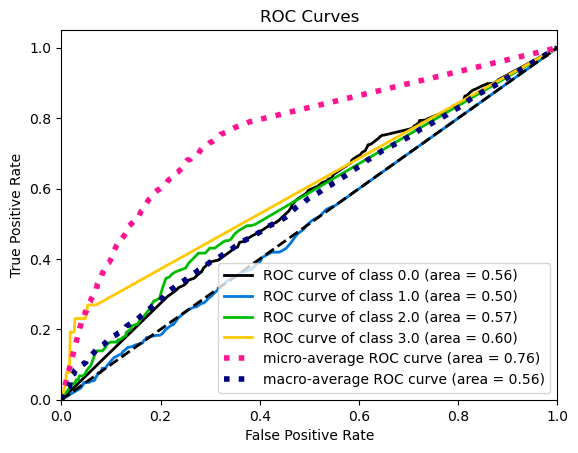

In [278]:
# roc
plot_roc(y_test, y_score)
plt.show()